# Lab: Support Vector Machines
*In this lab, we will apply Support Vector Machine (SVM) techniques using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
>
> * **Business Context:** Credit card fraud is a critical problem for financial institutions and payment processors, resulting in significant financial losses and eroding consumer confidence. As digital transactions become more common, the volume and sophistication of fraudulent activity continue to increase, challenging traditional detection methods.
> * **Business Problem:** The current approach to identifying fraudulent transactions is largely reactive and relies on static rules or manual review. This results in delayed detection, increased operational costs, and dissatisfied customers who experience either false alarms or undetected fraudulent charges on their accounts.
> * **Project Goal:** The objective of this project is to enable the early and accurate identification of fraudulent credit card transactions within a large volume of real-time payments. By moving from manual processes and fixed rules to an automated, data-driven system, the business aims to minimize financial losses, improve operational efficiency, and enhance the customer experience.
> * **Business Impact:** A successful solution would allow the company to:
>   - Prevent significant monetary losses caused by undetected fraudulent activity.
>   - Respond rapidly to suspicious transactions and deploy targeted interventions.
>   - Reduce false positives, minimizing unnecessary inconvenience for legitimate customers.
>   - Strengthen trust and brand reputation in a highly competitive financial market.

---

> ### 📝 2. Analytic Approach Report (Summary)
>
> * **Problem Type:** This is a classic **supervised binary classification problem**, where each credit card transaction must be classified as either “fraudulent” or “legitimate.” The dataset is highly imbalanced, with fraudulent transactions making up only a small fraction of total records.
> * **Modeling Approach:** To address the business objective, we will develop and evaluate a machine learning model that can automate the identification of fraudulent transactions. The main focus will be on applying **Support Vector Machines (SVM)**, a powerful family of classification algorithms well-suited for separating complex, high-dimensional data, especially after proper feature scaling.
> * **Handling Class Imbalance:** Due to the extreme imbalance in the dataset, special care will be taken to ensure the model does not default to predicting the majority class (legitimate transactions). Strategies may include:
>   - Using appropriate evaluation metrics that reflect performance on the minority (fraud) class.
>   - Exploring techniques such as data resampling, class weighting, or anomaly detection methods where relevant.
> * **Evaluation Metrics:** Given the cost of false negatives (missed fraud) and false positives (legitimate transactions flagged), multiple metrics will be applied:
>   - **Recall (Sensitivity):** Primary metric, maximizing the detection rate of fraudulent transactions.
>   - **Precision:** Identifying how many flagged cases are actually fraud.
>   - **F1-Score:** Balance between precision and recall.
>   - **ROC-AUC:** Performance across thresholds.
> Overall accuracy will **not** be the main metric due to class imbalance.
> * **Validation Strategy:** The dataset will be split into training and test subsets to fairly assess model generalization. 

---

> ### 📝 3. Data Requirements Report (Summary)
>
> * **Data Source:** The lab will use the widely recognized [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), which contains real transactions made by European cardholders in September 2013. The dataset consists of 284,807 transactions, with each row representing a single credit card transaction.
> * **Features (Independent Variables):**
>   - `V1`–`V28`: Result of a PCA transformation—these are anonymized, engineered features created by applying Principal Component Analysis (PCA) to the original card transaction variables to protect confidentiality.
>   - `Time`: Seconds elapsed between each transaction and the first transaction in the dataset.
>   - `Amount`: The transaction amount in $.
> * **Target (Dependent Variable):** `Class`: Binary label indicating transaction status (0 = legitimate, 1 = fraudulent).
> * **Granularity & Privacy:** Each row corresponds to an individual credit card transaction. Raw, identifying information (e.g., card number, merchant, location) is not included. All advanced feature columns except "Time" and "Amount" have been anonymized using PCA to preserve privacy. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection


In [20]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
warnings.filterwarnings("ignore", category=RuntimeWarning)

### 4.1 Extraction, Transformation, Loading
The data has already been download manually and saved as `../data/raw/creditcard.csv`. For this project, no further ETL process is needed.

### 4.4. Verification

In [2]:
raw_data_path = Path("../data/raw/creditcard.csv")

# Load the final interim data and verify its contents
try:
    df_verified = pd.read_csv(raw_data_path)
    print(f"Verification successful. The following DataFrame is ready for analysis with {df_verified.shape[0]} samples and {df_verified.shape[1]} features:")
    display(df_verified.sample(5))
except Exception as e:
    print(f"An error occurred while verifying the interim data: {e}")

Verification successful. The following DataFrame is ready for analysis with 284807 samples and 31 features:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
134994,81063.0,-0.765498,1.231004,1.082726,-0.183956,-0.192313,-0.444743,0.219281,0.543446,-0.762236,...,-0.159403,-0.573547,-0.018203,-0.023803,-0.165074,0.077460,0.134257,0.044977,2.69,0
130139,79292.0,0.728969,-2.219118,1.168378,-0.152064,-1.935126,1.538218,-1.519860,0.461513,0.780638,...,-0.180503,-0.203898,-0.427022,-0.723880,0.204815,1.277829,-0.012849,0.054006,298.00,0
141448,84329.0,-1.773046,1.409804,0.057910,0.925194,-0.995308,-0.213193,0.310643,0.734240,-0.296382,...,0.201739,0.405433,0.005983,0.045308,-0.324600,-0.323516,-0.295947,0.085984,111.05,0
228046,145335.0,-0.818584,-0.195745,2.813635,0.966857,-0.498193,0.687762,0.184075,0.051148,0.819200,...,0.305996,1.173848,-0.000920,0.091269,-0.009033,-0.470978,0.034595,-0.042700,135.34,0
39163,39720.0,1.018947,-0.073893,0.272303,1.136633,-0.543110,-0.767251,0.123546,-0.028810,-0.053623,...,0.126143,0.097177,-0.142760,0.507687,0.543280,-0.362230,-0.016825,0.023786,90.77,0



---

> ### 📝 4. Data Collection Report (Summary)
>
> * **Data Extraction:** The credit card transactions dataset was manually downloaded and placed in the project directory as `../data/raw/creditcard.csv`. No automated extraction was required for this lab.
> * **Transformation & Loading:** No additional data transformation or cleaning was performed at this stage. The raw file was loaded directly for analysis, preserving the original structure and content.
> * **Verification:** The raw data file was read successfully, verifying that it contains 284,807 records and 31 features, with a random sample confirming expected format and content for all columns.

---

## Stage 5: Data Understanding

### 5.1. Preparation for Exploratory Data Analysis (EDA)

In [3]:
# Copy the verified DataFrame for EDA
df_eda = df_verified.copy()

# Convert columns names to lowercase
df_eda.columns = df_eda.columns.str.lower()

# Create useful data structures and columns
numeric_cols = ["time", "amount", "class"]
numeric_features = ["time", "amount"]
df_eda['class_label'] = df_eda['class'].map({0: 'Normal', 1: 'Fraud'})

# Final check for the column names, data types, null values, and memory usage
print(f"  Column names: {df_eda.columns.to_list()}")
print("  Numerical Columns Info:")
df_eda[numeric_cols].info()

  Column names: ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class', 'class_label']
  Numerical Columns Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    284807 non-null  float64
 1   amount  284807 non-null  float64
 2   class   284807 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 6.5 MB


- 📌 The dataset contains **284,807 records** and **31 columns** (features), including both anonymized features (v1–v28) and interpretable fields (`time`, `amount`, `class`).
- 📌 **No missing values** were detected in the primary numeric columns Time, Amount, and Class—all rows are complete for these key fields.
- 📌 Data types are appropriate:  
  - “Time” and “Amount” are stored as `float64` (continuous).
  - “Class” is stored as `int64` (binary label: 0 = normal, 1 = fraud).
- 📌 The dataset is ready for detailed exploratory data analysis; no further cleaning is needed at this stage for these core variables.

### 5.2. Descriptive Statistics

In [4]:
# Generate the descriptive statistics for the numerical variables
stats_df = df_eda[numeric_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00,0.500857
amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16,2.831026
class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00,24.039094


- 📌 **Time:** Represents the relative timing of each transaction, not an actual timestamp. Ranges from `0` to `172,792` seconds (~48 hours), with a mean of ~94,814 seconds (~26.3 hours). Distribution is broad and relatively uniform (Coefficient of Variation ≈ 0.50). 
- 📌 **Amount:** Transaction amounts range from `0` to `$25,691.16`. Most transactions are small: 25th percentile is `5.6`, median is `22`, 75th percentile is `77.17`. The distribution is highly right-skewed: the mean (`88.35`) is much higher than the median (`22`), and the CV is very high (`2.83`), suggesting the presence of large outlier amounts.
- 📌 **Class:** Maximum is `1`, minimum is `0` (binary encoded). Mean value (`0.0017`) reflects extreme class imbalance: only about 0.17% of transactions are labeled as fraud (Class = 1). 25th, 50th, and 75th percentiles all are `0` (indicating legitimate), confirming that fraud is rare. Standard deviation (`0.0415`) and coefficient of variation (`24.0`) further reflect the rarity and strong imbalance of the minority class. 

### 5.3. Univariate Analysis

class_label
Normal    0.998273
Fraud     0.001727
Name: proportion, dtype: float64


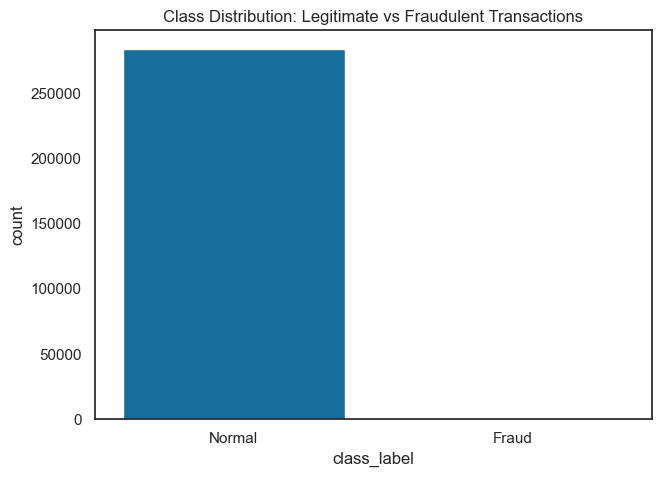

In [5]:
# Visually confirming the extreme class imbalance
print(df_eda['class_label'].value_counts(normalize=True))
sns.countplot(x='class_label', data=df_eda)
plt.title("Class Distribution: Legitimate vs Fraudulent Transactions")
plt.show()

- 📌 The class distribution plot **confirms extreme class imbalance**: an overwhelming majority of transactions are legitimate, with fraudulent transactions making up only a tiny fraction of the data. This highlights the need for careful metric selection and possibly targeted modeling techniques to detect rare fraud cases.

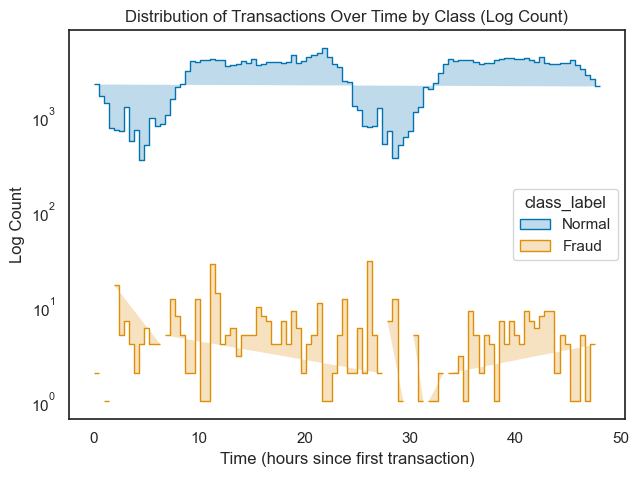

In [6]:
# Distribution of fraudulent and normal transactions by time
sns.histplot(
    df_eda,
    x=df_eda["time"] / 3600,
    hue="class_label",
    bins=100,
    log_scale=(False, True),
    element="step"
)
plt.title("Distribution of Transactions Over Time by Class (Log Count)")
plt.xlabel("Time (hours since first transaction)")
plt.ylabel("Log Count")
plt.show()

- 📌 The distribution of transactions over time reveals **two distinct peaks for normal (legitimate) transactions**, suggesting periodic or batch activity patterns in the dataset. In contrast, fraudulent transactions do **not exhibit any strong temporal clustering**, appearing relatively evenly distributed across the available time range. This indicates that time-based filtering alone is unlikely to isolate fraud but could inform further feature engineering or temporal analysis.

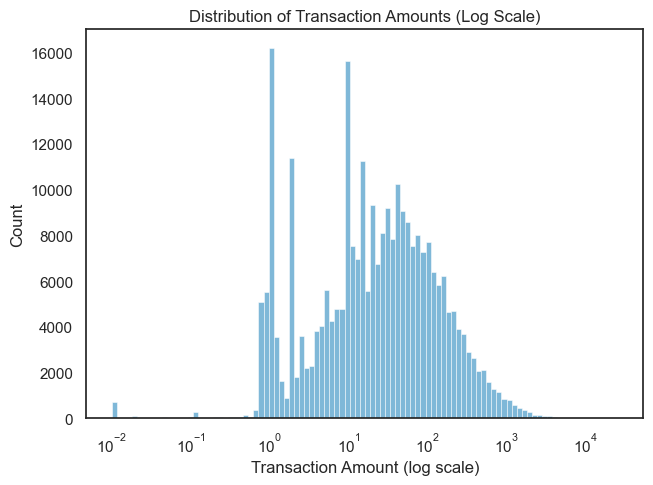

In [7]:
# Histogram of the amount variable (log scale for x-axis)
sns.histplot(df_eda, x='amount', bins=100, kde=True, log_scale=(True, False))
plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Count")
plt.show()

- 📌 The transaction amounts are **highly right-skewed**: while the vast majority of transactions occur at low values, there are a small number of transactions with very large amounts, as highlighted by the log-scaled histogram. This pattern is consistent with the descriptive statistics, where the mean far exceeds the median and extreme outliers are present. Caution is warranted in modeling, as standardization or transformation of the "Amount" feature may be beneficial.

### 5.4. Bivariate Analysis

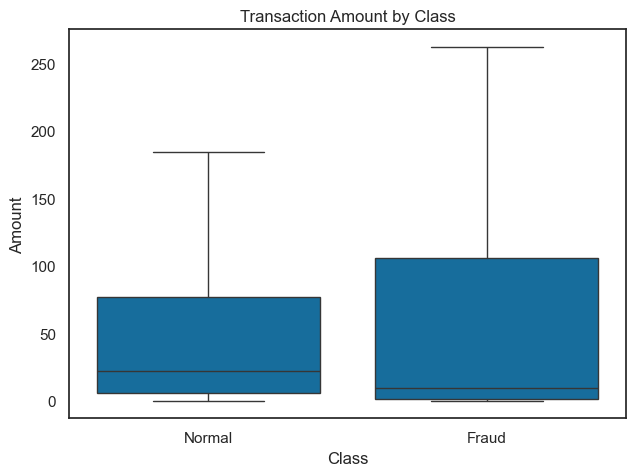

In [8]:
# Compare the distribution of `amount` for normal and fraud transactions
sns.boxplot(x="class_label", y="amount", data=df_eda, showfliers=False)
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

- 📌 Comparing transaction amounts by class reveals that while **fraudulent transactions tend to have a wider range and higher maximum values, the upper quartiles (Q3 and max) are significantly greater for fraud** than for normal transactions. In contrast, the median and lower quartile (Q1) for normal transactions are somewhat higher, but the most extreme values (large amounts) are more likely to be associated with fraud. This suggests high-value transactions may warrant closer scrutiny for potential fraud.

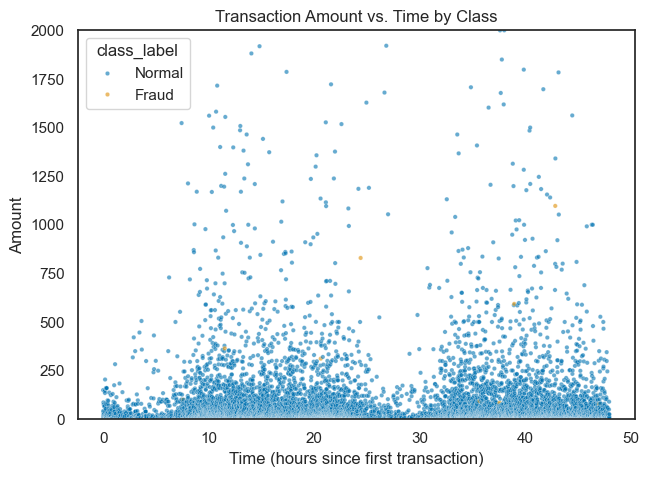

In [9]:
# Plot amount against time, colored by class to see if fraud clusters in amount/time space.
sns.scatterplot(
    x=df_eda["time"] / 3600,
    y="amount",
    hue="class_label",
    data=df_eda.sample(10000, random_state=42),  # Only a sample for plotting speed!
    alpha=0.6,
    s=10,
)
plt.title("Transaction Amount vs. Time by Class")
plt.xlabel("Time (hours since first transaction)")
plt.ylabel("Amount")
plt.ylim(0, 2000)   # Optional: focus on reasonable amounts
plt.show()

- 📌 The scatterplot of transaction amount versus time shows that **fraudulent transactions (yellow) are scattered throughout the time and amount range**, with no obvious clustering or concentration in particular periods or value bands. The overwhelming majority of transactions are legitimate (blue), making it visually difficult to discern fraud patterns due to their rarity. This further underscores the challenge posed by class imbalance and suggests that fraud detection cannot rely solely on simple thresholds or two-dimensional patterns involving time and amount.

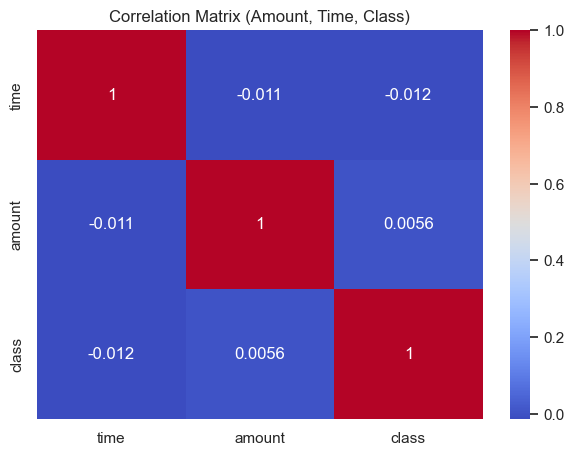

In [10]:
# Correlation heatmap
corr = df_eda[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Amount, Time, Class)")
plt.show()

- 📌 The correlation heatmap shows that **there is virtually no linear relationship between transaction time, transaction amount, and the fraud label** (all correlation coefficients are very close to zero). This suggests that neither time nor amount alone can directly predict fraud through simple linear associations, reinforcing the need for more complex modeling approaches and the use of additional features.

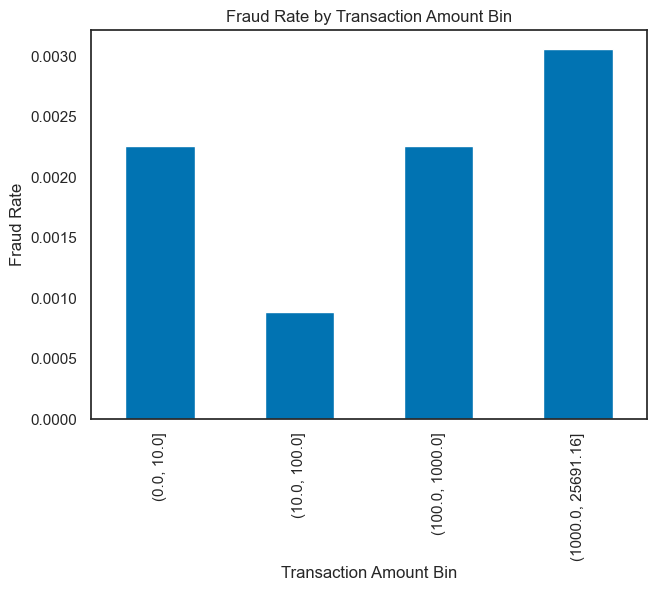

In [11]:
# Fraud rate across amount ranges
bins = [0, 10, 100, 1000, df_eda["amount"].max()]
df_eda["amount_bin"] = pd.cut(df_eda["amount"], bins=bins)
fraud_rates = df_eda.groupby("amount_bin", observed=False)["class"].mean()
fraud_rates.plot(kind="bar")
plt.title("Fraud Rate by Transaction Amount Bin")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Amount Bin")
plt.show()

- 📌 Analysis of fraud rates across transaction amount bins reveals that **fraud is more prevalent among the largest transactions**, with the highest bin showing a notably greater fraud rate (over 0.3%) compared to lower amount brackets. The lowest fraud rate occurs in small-to-moderate transactions ($10–$100), indicating that high-value transactions are disproportionately targeted or associated with fraudulent activity. This finding supports close monitoring of large transactions in fraud detection systems.

---

> ### 📝 5. Data Understanding Report (Summary)
>
> - The dataset comprises 284,807 transactions with 31 features, including time, amount, and a binary fraud label. All records are complete for these key variables.
> - There is **extreme class imbalance**: only about 0.17% of transactions are fraudulent, with the rest being legitimate. This underscores the importance of using appropriate evaluation metrics and model strategies.
> - Both the **"Time"** and **"Amount"** features exhibit wide ranges. "Time" spans approximately 48 hours and shows two periods of heightened transaction activity for legitimate cases, but no notable temporal clustering for fraud.
> - The **amount variable is highly right-skewed**: most transactions are of low value, but some reach very high amounts. Boxplot analysis indicates that large-amount transactions are disproportionately associated with fraud, especially in the highest value bin.
> - Correlation analysis reveals **no strong linear relationships** among time, amount, and fraud labels, reinforcing the need for advanced, nonlinear modeling.
> - Given these characteristics, a Support Vector Machine (SVM) approach is suitable as it can handle complex, high-dimensional, and imbalanced classification tasks, especially when combined with feature scaling and appropriate evaluation metrics.

---

## Stage 6: Data Preparation
For this dataset, no additional data cleaning or feature engineering steps are needed. We proceed directly to constructing the final feature matrix and target vector, followed by splitting the data into training and test sets with stratification to maintain class proportions.

We also need to scale the features with StandardScaler, because SVMs are sensitive to feature scales.

In [12]:
# Create the final features matrix and the target vector
final_features = ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount']
X = df_eda[final_features]
y = df_eda["class"]

In [13]:
# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

> ### 6. Data Preparation Report (Summary)
>
> - No additional data cleaning or feature engineering was necessary, as the dataset was already complete, numeric, and free of missing or anomalous values.
> - The final feature matrix includes all original variables except the target (`class`), specifically: `time`, `v1` through `v28`, and `amount`.
> - The target vector is the `class` label, with 0 for legitimate transactions and 1 for fraud.
> - The dataset was split into training (80%) and test (20%) sets using stratification to maintain the extreme class imbalance in both splits.
> - All input features were standardized separately for the training and test sets using `StandardScaler`. This ensures that the SVM model can perform optimally and treats all features on an equal scale.

---

## Stage 7: Modeling
Since this is a lab project for SVMs only, we won't be training any other baseline or candidate models.

In [15]:
# Create the SVC model
clf = SVC(class_weight="balanced", probability=True, random_state=42)

In [16]:
# Train the model
clf.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False



---

> ### 📝 7. Modeling (Summary)
>
> - The Support Vector Classifier (SVC) from scikit-learn was selected as the sole model for this stage, in line with project goals. The model was trained on standardized features, and optionally configured to account for class imbalance. No alternative baseline models were included.

---

## Stage 8: Evaluation

### 8.1. Performance on the Hold-Out Test Set

In [17]:
# Make predictions on the test set
y_pred = clf.predict(X_test_scaled)

In [19]:
# Calculate and print evaluation metrics
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"  F1-Score: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

Evaluation Metrics:
  F1-Score: 0.4512
  Precision: 0.3217
  Recall: 0.7551


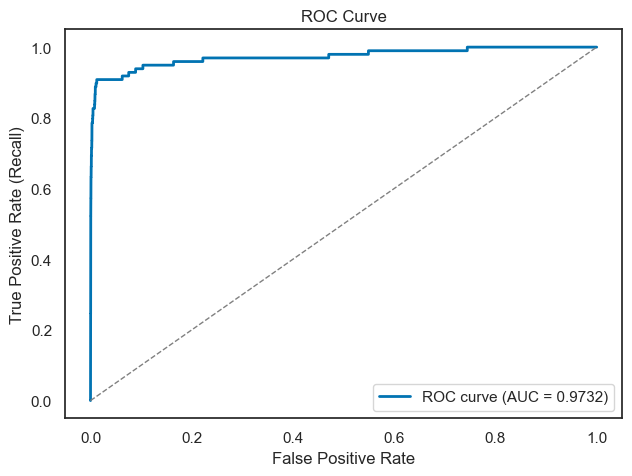

In [21]:
# Get probabilities of being fraud
y_scores = clf.predict_proba(X_test_scaled)[:,1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# Plot
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")  # Random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()


---

> ### 📝 8. Evaluation Report (Summary)
>
> - The SVM model was evaluated on a hold-out test set using multiple metrics tailored for highly imbalanced fraud detection tasks.
>    - **Recall:** 0.7551. The model correctly identified 75.5% of fraudulent transactions, achieving strong sensitivity, which is vital for minimizing missed frauds.
>   - **Precision:** 0.3217. About 32% of transactions flagged as fraud were truly fraudulent, reflecting the challenge of maintaining high precision when recall is prioritized in a rare-event setting.
>   - **F1-Score:** 0.4512. The harmonic mean of precision and recall offers a balanced summary of the model's effectiveness under class imbalance.
>   - **ROC-AUC:** 0.9732. The model exhibited excellent ability to distinguish fraud from legitimate transactions across all classification thresholds, confirming strong learning and ranking capacity.
> - **Overall accuracy was not used as the primary metric** due to extreme class imbalance, which can make accuracy figures misleading in fraud detection.
> - **Note on methodology:** At this stage in the course, we have **not applied advanced best practices such as cross-validation or systematic hyperparameter tuning** (e.g., GridSearchCV). The SVM was evaluated with default parameters aside from class balancing, and no threshold adjustment or advanced resampling was performed. These improvements will be addressed in future modules, as our focus here was to build foundational understanding of SVMs and performance metrics for imbalanced classification problems.
> - **Next steps:** Future work will revisit this model using more advanced evaluation and optimization strategies once those techniques are introduced in the curriculum.

---

**Next:** [KNN Theory](./17_knn_theory.md)